# Random System Analysis
This notebook generates a random transfer function of a specified order and plots the:
1. root locus
2. Bode plot
3. Nyquist plot
4. Nichols chart
5. Inverse Nichols chart
6. step response

In [ ]:
# setup
from control import *
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
sym.init_printing()

pole_colours = ['xkcd:bright pink',
                'xkcd:bright purple',
                'xkcd:bright blue',
                'xkcd:bright green',
                'xkcd:bright orange',
                'xkcd:red',
                'xkcd:aqua',
                'xkcd:bright pink',
                'xkcd:bright purple',
                'xkcd:bright blue',
                'xkcd:bright green',
                'xkcd:bright orange',
                'xkcd:red',
                'xkcd:aqua']
%matplotlib inline

In [ ]:
# transfer function
pole_lim = [-10,0] # range of possible pole values
zero_lim = [-10,5] # range of possible zero values
im_lim = [0,5] # range of values for imaginary part of either pole or zero

n = 4 # number of poles
m = np.random.randint(0,n+1) # number of zeros

s = sym.symbols('s')

poles = []
while len(poles) < n:
    is_complex = np.random.uniform(0,1) < 0.5 # chance that pole will be complex
    if is_complex and len(poles) < n-1:
        
#         integer values only
        real = np.random.randint(pole_lim[0],pole_lim[1])
        im = np.random.randint(im_lim[0],im_lim[1])
        
        # random floats
#         real = np.random.uniform(pole_lim[0],pole_lim[1])
#         im = np.random.uniform(im_lim[0],im_lim[1])
        
        poles.append(real + 1j*im)
        poles.append(real - 1j*im)
    else:
        poles.append(np.random.randint(pole_lim[0],pole_lim[1]))
#         poles.append(np.random.uniform(pole_lim[0],pole_lim[1]))

D = sym.Poly(np.prod([(s - p) for p in poles])) # denominator
Dc = D.coeffs() # denominator coefficients

zeros = []
while len(zeros) < m:
    is_complex = np.random.uniform(0,1) < 0.5 # chance that zero will be complex
    if is_complex and len(zeros) < m-1:
        
#         # integer values only
        real = np.random.randint(zero_lim[0],zero_lim[1])
        im = np.random.randint(im_lim[0],im_lim[1])
        
#         random floats
#         real = np.random.uniform(zero_lim[0],zero_lim[1])
#         im = np.random.uniform(im_lim[0],im_lim[1])
        
        zeros.append(real + 1j*im)
        zeros.append(real - 1j*im)
    else:
        zeros.append(np.random.randint(zero_lim[0],zero_lim[1]))
#         zeros.append(np.random.uniform(zero_lim[0],zero_lim[1]))

if len(zeros) == 0:
    Nc = [1]
    gain = np.abs(1/np.prod(poles))
else:
    N = sym.Poly(np.prod([(s - z) for z in zeros])) # numerator
    Nc = N.coeffs() # numerator coefficients
    gain = np.abs(np.prod(zeros)/np.prod(poles))

# create transfer function
gain_out = np.random.uniform(0.1,10)
A = gain_out/gain
Q = tf([A*complex(c) for c in Nc],[complex(c) for c in Dc])
Q

## Poles and Zeros

In [ ]:
# pole and zero plot
print('poles:')
print(poles)
print('zeros:')
print(zeros)
print('gain: ')
print(gain_out)

fig, ax = plt.subplots(1,1,figsize = [4,4])
# ax.set_xticks([0])
# ax.set_yticks([0])
cf = np.concatenate([poles,zeros])
xrange = [np.floor(min(np.real(cf)))-1,np.ceil(max(np.real(cf)))+1]
yrange = [np.floor(min(np.imag(cf)))-1,np.ceil(max(np.imag(cf)))+1]
ax.set_xticks(np.arange(xrange[0],xrange[1],1))
ax.set_yticks(np.arange(yrange[0],yrange[1],1))
ax.set_xticks(np.arange(xrange[0],xrange[1],0.2),minor=True)
ax.set_yticks(np.arange(yrange[0],yrange[1],0.2),minor=True)
ax.set_xlim(xrange)
ax.set_ylim(yrange)
ax.grid(which='major',color='xkcd:grey')
ax.grid(which='minor',color='xkcd:light grey')
ax.plot(xrange,[0,0],color='black')
ax.plot([0,0],yrange,color='black')

for p_i,p in enumerate(poles):
    ax.plot(np.real(p),np.imag(p),marker='X',markersize = 10,color = pole_colours[p_i])
for z in zeros:
    ax.plot(np.real(z),np.imag(z),marker='o',markerfacecolor = 'none',markeredgecolor = 'black',markersize = 10)

## Step Response

In [ ]:
t_end = 5
t_step = 0.02
t = np.arange(0,t_end,t_step)
t,y = step_response(Q,T = t)

fig, ax = plt.subplots(1,1,figsize=[4,4])
ax.plot(t,y)
ax.set_xlabel('time')
ax.set_ylabel('output')

ax.set_yticks(np.arange(0,np.ceil(max(y)),1),minor=False)
ax.set_yticks(np.arange(np.floor(min(y)),np.ceil(max(y)),0.2),minor=True)
ax.set_ylim([np.floor(min(y)),1.05*np.ceil(max(y))])

ax.set_xticks(np.arange(0,t_end,1),minor=False)
ax.set_xticks(np.arange(0,t_end,0.1),minor=True)
ax.set_xlim([0,t_end])
ax.grid(which='major',color='xkcd:grey')
ax.grid(which='minor',color='xkcd:light grey')

## Root Locus

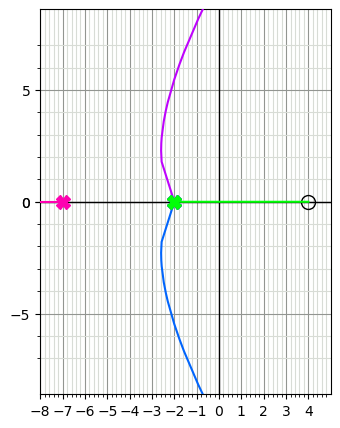

In [42]:
%matplotlib inline
rldata = root_locus_map(Q) 
rlist = rldata.loci
klist = rldata.gains

# plot parameters
fig,ax = plt.subplots(1,1,figsize=[5,5])

ax.set_aspect('equal')
ymax = np.max(np.abs([rlist[i][p] for i in range(len(rlist[p])) for p in range(np.shape(rlist)[1])]))

xrange = [np.floor(min(np.real(cf)))-1,np.ceil(max(np.real(cf)))+1]
yrange = [-ymax-1,ymax+1]

ax.plot(xrange,[0,0],linewidth=1,color='black')
ax.plot([0,0],yrange,linewidth=1,color='black')

if ymax < 5:
    y_increment = 1
else:
    y_increment = 5

ax.set_xticks(np.arange(xrange[0],xrange[1],1))
ax.set_yticks(np.concatenate([np.arange(0,-ymax,-y_increment),np.arange(0,ymax,y_increment)]))

ax.set_xticks(np.arange(xrange[0],xrange[1],0.2),minor=True)
ax.set_yticks(np.concatenate([np.arange(0,-ymax,-y_increment/5),np.arange(0,ymax,y_increment/5)]),minor=True)

ax.set_xlim(xrange)
ax.set_ylim(yrange)
ax.grid(which='major',color='xkcd:grey',zorder=-10)
ax.grid(which='minor',color='xkcd:light grey',zorder=-10)
    
for z in zeros:
    ax.plot(np.real(z),np.imag(z),marker='o',markerfacecolor = 'none',markeredgecolor = 'black',markersize = 10,zorder=10)

for p in range(np.shape(rlist)[1]):
    root = [rlist[i][p] for i in range(len(rlist))]
    ax.plot(np.real(root[0]),np.imag(root[0]),marker='X',markersize = 10,color = pole_colours[p],zorder=20)
    ax.plot(np.real(root),np.imag(root),color=pole_colours[p],zorder=20)

# ------------------------------------------------------------------------------------------------------------------------------------------------------
# annotation:
anno_gains = [] # gains you want annotated on the root locus

# k_index = np.floor(np.linspace(0,len(klist)-1,10))
# anno_gains = [klist[int(i)] for i in k_index]
# anno_data = root_locus_map(Q,anno_gains) 
# anno_rlist = anno_data.loci

if len(anno_gains):
    x_offset = 0.07
    y_offset = 0
    
    for p in range(np.shape(rlist)[1]):
        for i in range(len(anno_gains)):
            x = np.real(anno_rlist[i][p])
            y = np.imag(anno_rlist[i][p])
            ax.scatter(x,y,color='black',zorder=20)
            if x > xrange[0] and x < xrange[1] and y > yrange[0] and y < yrange[1]:
                ax.text(x+x_offset,y+y_offset,'%.1f'%anno_gains[i],zorder=30)

## Bode Plot

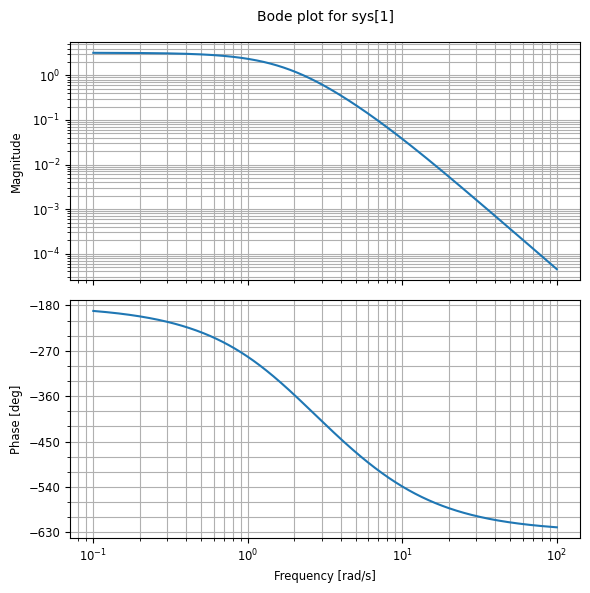

In [43]:
%matplotlib inline
omegalist = np.linspace(0,10000,100000) # if you want to specify a frequency range.
                                    # otherwise, if you leave out the omega argument, it will automatically choose.
fig = plt.figure(figsize=[6,6])
bode_plot(Q)

# Nyquist plot

C:\Users\27844\anaconda3\Lib\site-packages\control\xferfcn.py:1087: ComplexWarning: Casting complex values to real discards the imaginary part
  den[j, :maxindex+1] = poly(poles[j])
C:\Users\27844\anaconda3\Lib\site-packages\control\xferfcn.py:1117: ComplexWarning: Casting complex values to real discards the imaginary part
  num[i, j, maxindex+1-len(numpoly):maxindex+1] = numpoly


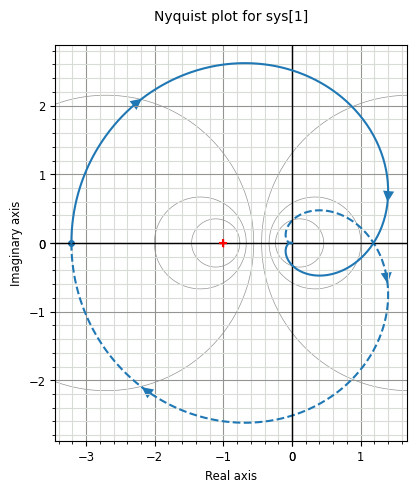

In [51]:
mag, phase, omega = frequency_response(Q)

cplt = nyquist(Q) # labelFreq = n means label every nth frequency value
fig = cplt.figure

ax = cplt.axes[0][0]


xrange = ax.get_xlim()
yrange = ax.get_ylim()

x_increment = 1
y_increment = 1

ax.set_xticks(np.concatenate([np.arange(0,-np.max(np.abs(xrange)),-x_increment),np.arange(0,np.max(np.abs(xrange)),x_increment)]))
ax.set_yticks(np.concatenate([np.arange(0,-np.max(np.abs(yrange)),-y_increment),np.arange(0,np.max(np.abs(yrange)),y_increment)]))

ax.set_xticks(np.concatenate([np.arange(0,-np.max(np.abs(xrange)),-x_increment/5),np.arange(0,np.max(np.abs(xrange)),x_increment/5)]),minor=True)
ax.set_yticks(np.concatenate([np.arange(0,-np.max(np.abs(yrange)),-y_increment/5),np.arange(0,np.max(np.abs(yrange)),y_increment/5)]),minor=True)

ax.grid(which='major',color='xkcd:grey',zorder=0)
ax.grid(which='minor',color='xkcd:light grey',zorder=0)

ax.plot(xrange,[0,0],linewidth=1,color='black',zorder=2)
ax.plot([0,0],yrange,linewidth=1,color='black',zorder=2)
ax.scatter([-1],[0],marker='+',color='red',zorder=100)

ax.set_xlim(xrange)
ax.set_ylim(yrange)


# there aren't M and N circles, so I wrote a function to add them
def m_circle_nyquist(M):
    if M == 1:
        re = -0.5*np.ones(10000)
        im = np.linspace(-1000,1000,10000)
    else:
        r = M/(M**2 - 1)
        re_c = -(M**2)/(M**2 - 1)
        thv = np.linspace(0,2*np.pi,10000)
        re = [re_c + r*np.cos(th) for th in thv]
        im = [r*np.sin(th) for th in thv]
    return re, im
        
def n_circle_nyquist(th):
    N = np.tan(th*np.pi/180)
    r = 0.5*np.sqrt(1 + 1/(N**2))
    re_c = -0.5
    im_c = 1/(2*N)
    if th == -180:
        re = np.linspace(-1,0,10000)
        im = np.zeros(10000)
    else:
        thv = np.linspace(0,2*np.pi,10000)
        re = [re_c + r*np.cos(th) for th in thv]
        im = [im_c + r*np.sin(th) for th in thv]
    return re, im

# Which M and N circles to display
# magnitudes = [-35,-30,-25,-20,-15,-10,-5,-3,-2,-1,-0.5,-0.2,0,0.2,0.5,1,2,3,6,10]
magnitudes = [-10,-6,-2,2,6,10]
# angles = [-270,-180,-90,-60,-45,-30,-15]
angles = []

for M in magnitudes:
    re,im = m_circle_nyquist(10**(M/20))
    ax.plot(re,im,linewidth=0.5,color='xkcd:grey',zorder=-10)

for th in angles:
    re,im = n_circle_nyquist(th)
    ax.plot(re,im,linestyle = '--',linewidth=0.5,color='xkcd:grey',zorder=-10)

for line in cplt.lines:
    line[0].zorder=10

ax.set_aspect('equal')

fig.set_dpi(100)
fig.set_size_inches(5,5)

# Nichols chart

In [52]:
def better_nichols(Q,ax,inverse=False,**kwargs):
    if 'magnitudes' in kwargs.keys():
        magnitudes = kwargs['magnitudes']
    else:
        magnitudes = [-35,-30,-25,-20,-15,-10,-5,-4,-3,-2,-1,-0.5,-0.2,0,0.2,0.5,1,2,3,6,10] # in dB
    if 'angles' in kwargs.keys():
        magnitudes = kwargs['angles']
    else:
        angles = [-180,-90,-60,-45,-30,-15] # in deg
    if 'color' in kwargs.keys():
        color = kwargs['color'] 
    else:
        color = 'blue'
       
    def m_circle_nichols(M):
        re, im = m_circle_nyquist(M)

        mag = np.array([20*np.log10(np.abs(re[i] + im[i]*1j)) for i in range(len(re))])
        phase_raw = np.array([np.angle(re[i] + im[i]*1j)*180/np.pi for i in range(len(re))])

        # wrapping
        phase = np.array([th if th <= 0 else th - 360 for th in phase_raw])
        if M < 1:
            phase_order = np.argsort(phase)
            return mag[phase_order], phase[phase_order]
        else:
            return mag, phase
    
    def n_circle_nichols(th):
        re, im = n_circle_nyquist(th)

        mag = np.array([20*np.log10(np.abs(re[i] + im[i]*1j)) for i in range(len(re))])
        phase_raw = np.array([np.angle(re[i] + im[i]*1j)*180/np.pi for i in range(len(re))])

        # wrapping
        phase = np.array([th if th <= 0 else th - 360 for th in phase_raw])
        phase_order = np.argsort(phase)
        return mag[phase_order], phase[phase_order]

    for M in magnitudes:
        mag, phase = m_circle_nichols(10**(M/20))
        if inverse:
            mag = -mag
            phase = -phase-360
        ax.plot(phase,mag,linewidth=1,color='xkcd:light blue')
        if inverse:
            ax.annotate('%.1f'%M,[phase[0],np.min(mag)])
        else:
            ax.annotate('%.1f'%M,[phase[0],np.max(mag)])
    
    for th_i,th in enumerate(angles):
        N = np.tan(th*np.pi/180)
        mag, phase = n_circle_nichols(th)
        if inverse:
            mag = -mag
            phase = -phase-360
        ax.plot(phase,mag,linestyle = '--',linewidth=1,color='xkcd:light blue')
        if inverse:
            ax.annotate('%.1f'%th,[np.min(phase),5*th_i])
        else:
            ax.annotate('%.1f'%th,[np.max(phase),-5*th_i])

    if 'omega' in kwargs.keys():
        mag, phase, omega = frequency_response(Q,omega = kwargs['omega'])
    else:
        mag, phase, omega = frequency_response(Q)
    phase = np.array([th if th <= 0 else th - np.pi*2 for th in phase])
    ax.plot(phase*180/np.pi,20*np.log10(mag),color=color,zorder=10)

    ax.plot([-180],[0],marker='+',markersize=10,color='red',zorder=100)

    if 'anno_omega' in kwargs.keys():
        mag, phase, omega = frequency_response(Q,omega = kwargs['anno_omega'])
        for i in range(len(mag)):
            x = phase[i]*180/np.pi
            y = 20*np.log10(mag[i])

            if 'yoff' in kwargs.keys():
                yoff = kwargs['yoff']
            else:
                yoff = -1

            if 'xoff' in kwargs.keys():
                xoff = kwargs['xoff']
            else:
                xoff = 5
            
            ax.scatter([x],[y],color=color,zorder=10)
            ax.text(x+xoff,y+yoff,'%.1f'%omega[i],zorder=200)

C:\Users\27844\AppData\Local\Temp\ipykernel_7856\2911092177.py:32: RuntimeWarning: divide by zero encountered in log10
  mag = np.array([20*np.log10(np.abs(re[i] + im[i]*1j)) for i in range(len(re))])


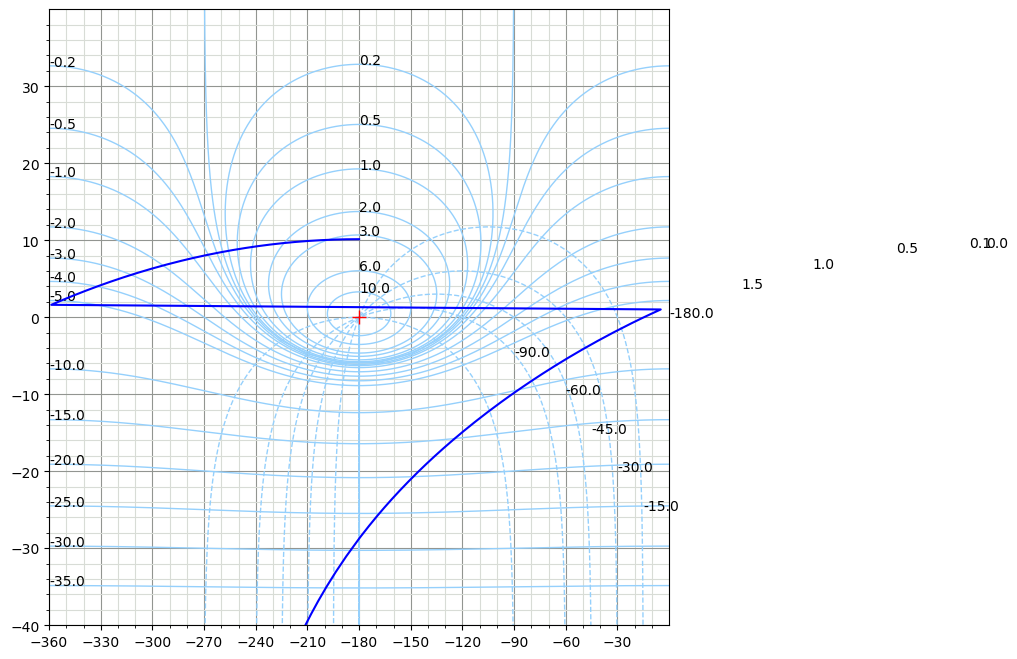

In [54]:
omegalist = np.concatenate([k*np.linspace(0,10,100) for k in [0.01,0.1,1,10,100,1000]])
fig,ax = plt.subplots(1,1,figsize=[8,8],dpi=100)

better_nichols(Q,ax,False,omega = omegalist,anno_omega = [0.01,0.1,0.5,1,1.5],color='blue',yoff=-1,xoff=5)
ax.set_xlim([-360,0])
ax.set_ylim([-40,40])
ax.set_xticks(range(-360,0,30))
ax.set_xticks(range(-360,0,10),minor=True)
ax.set_yticks(range(-40,40,10))
ax.set_yticks(range(-40,40,2),minor=True)
ax.grid(which='major',color='xkcd:grey')
ax.grid(which='minor',color='xkcd:light grey')


# Inverse Nichols

C:\Users\27844\AppData\Local\Temp\ipykernel_7856\2911092177.py:32: RuntimeWarning: divide by zero encountered in log10
  mag = np.array([20*np.log10(np.abs(re[i] + im[i]*1j)) for i in range(len(re))])


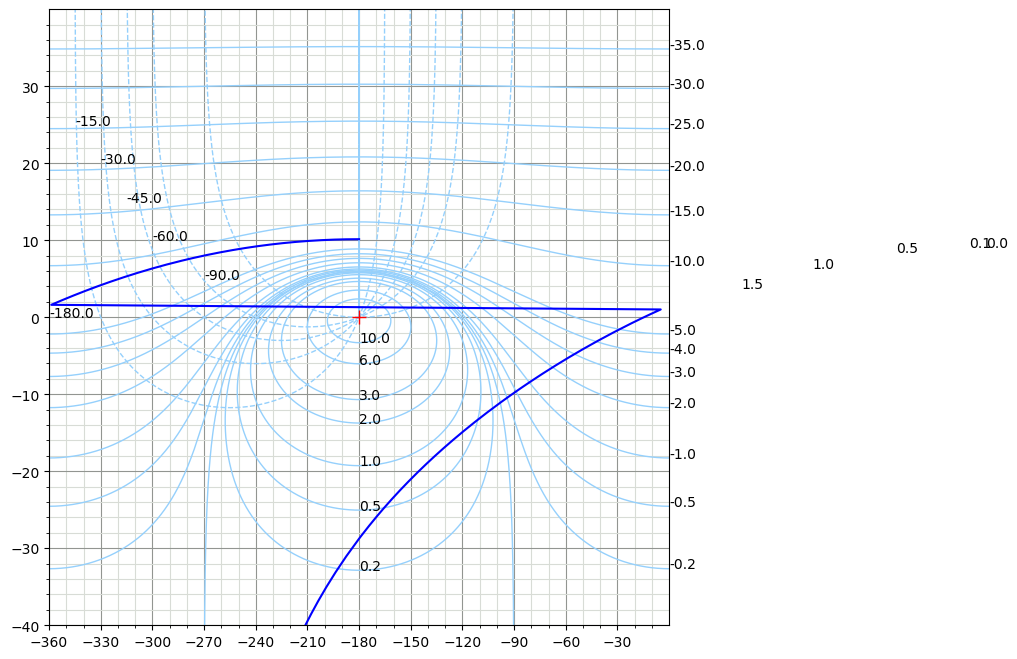

In [53]:
omegalist = np.concatenate([k*np.linspace(0,10,100) for k in [0.01,0.1,1,10,100,1000]])
fig,ax = plt.subplots(1,1,figsize=[8,8],dpi=100)

better_nichols(Q,ax,True,omega = omegalist,anno_omega = [0.01,0.1,0.5,1,1.5],color='blue',yoff=-1,xoff=5)
ax.set_xlim([-360,0])
ax.set_ylim([-40,40])
ax.set_xticks(range(-360,0,30))
ax.set_xticks(range(-360,0,10),minor=True)
ax.set_yticks(range(-40,40,10))
ax.set_yticks(range(-40,40,2),minor=True)
ax.grid(which='major',color='xkcd:grey')
ax.grid(which='minor',color='xkcd:light grey')
